# Ranking Comparativo de Modelos de Machine Learning

Este notebook gera dinamicamente um ranking de todos os modelos treinados, agrupados por:
- **Tipo de problema**: Regressão vs Classificação
- **Janela de tempo**: 3, 7, 15 e 30 dias

Os dados são carregados automaticamente a partir dos CSVs de métricas gerados no treinamento.

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

## 1. Coleta Dinâmica dos CSVs de Métricas

In [6]:
MODELS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'models')

# Mapeamento de modelos para tipo de problema
MODELOS_REGRESSAO = {'regressao_linear', 'regressao_linear_rede_neural'}
MODELOS_CLASSIFICACAO = {'regressao_logistica', 'random_forest', 'xgboost'}

# Nomes amigáveis para exibição
NOMES_MODELOS = {
    'regressao_linear': 'Regressão Linear',
    'regressao_linear_rede_neural': 'Rede Neural (Regressão)',
    'regressao_logistica': 'Regressão Logística',
    'random_forest': 'Random Forest',
    'xgboost': 'XGBoost',
}

NOMES_DATASETS = {
    'dataset_base': 'Base',
    'dataset_dummy': 'Dummy',
    'dataset_indicadores': 'Indicadores',
    'dataset_janelas': 'Janelas',
}

HORIZONTES = ['3 dias', '7 dias', '15 dias', '30 dias']

print(f'Diretório dos modelos: {MODELS_DIR}')
print(f'Existe: {os.path.exists(MODELS_DIR)}')

Diretório dos modelos: /home/gabriel/Documents/GIT/Analise-comparativa-de-modelos-de-machine-learning---Agro-Brasil---TCC/models
Existe: True


In [7]:
def coletar_metricas(models_dir):
    """
    Varre dinamicamente o diretório de modelos e coleta todos os CSVs de métricas.
    Retorna um DataFrame consolidado com colunas extras:
    - modelo, dataset, ticker, tipo (regressao/classificacao)
    """
    registros = []
    
    csv_files = glob.glob(os.path.join(models_dir, '**', '*.csv'), recursive=True)
    print(f'Total de arquivos CSV encontrados: {len(csv_files)}')
    
    for csv_path in csv_files:
        # Extrair informações do caminho
        # Estrutura: models/<modelo>/<dataset>/<subpasta>/metricas_<ticker>_<sufixo>.csv
        rel_path = os.path.relpath(csv_path, models_dir)
        parts = rel_path.split(os.sep)
        
        if len(parts) < 3:
            continue
        
        modelo = parts[0]       # ex: regressao_linear
        dataset = parts[1]      # ex: dataset_janelas
        
        # Extrair ticker do nome do arquivo
        filename = os.path.basename(csv_path)
        ticker = None
        for t in ['agro3', 'slce3', 'soja3']:
            if t in filename.lower():
                ticker = t.upper()
                break
        
        if ticker is None:
            continue
        
        # Determinar tipo
        if modelo in MODELOS_REGRESSAO:
            tipo = 'regressao'
        elif modelo in MODELOS_CLASSIFICACAO:
            tipo = 'classificacao'
        else:
            continue
        
        # Ler CSV
        try:
            df = pd.read_csv(csv_path)
            # Normalizar nome da coluna R² / R2
            df.columns = [c.replace('R²', 'R2') for c in df.columns]
            
            df['modelo'] = modelo
            df['modelo_nome'] = NOMES_MODELOS.get(modelo, modelo)
            df['dataset'] = dataset
            df['dataset_nome'] = NOMES_DATASETS.get(dataset, dataset)
            df['ticker'] = ticker
            df['tipo'] = tipo
            
            registros.append(df)
        except Exception as e:
            print(f'Erro ao ler {csv_path}: {e}')
    
    if not registros:
        print('Nenhum registro encontrado!')
        return pd.DataFrame()
    
    df_all = pd.concat(registros, ignore_index=True)
    print(f'Total de registros coletados: {len(df_all)}')
    print(f'Modelos encontrados: {sorted(df_all["modelo"].unique())}')
    print(f'Datasets encontrados: {sorted(df_all["dataset"].unique())}')
    print(f'Tickers encontrados: {sorted(df_all["ticker"].unique())}')
    print(f'Tipos: {sorted(df_all["tipo"].unique())}')
    return df_all

df_all = coletar_metricas(MODELS_DIR)
df_all.head()

Total de arquivos CSV encontrados: 60
Total de registros coletados: 240
Modelos encontrados: ['random_forest', 'regressao_linear', 'regressao_linear_rede_neural', 'regressao_logistica', 'xgboost']
Datasets encontrados: ['dataset_base', 'dataset_dummy', 'dataset_indicadores', 'dataset_janelas']
Tickers encontrados: ['AGRO3', 'SLCE3', 'SOJA3']
Tipos: ['classificacao', 'regressao']


,Horizonte,R2,MAE,RMSE,modelo,modelo_nome,dataset,dataset_nome,ticker,tipo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,3 dias,0.9392,0.3518,0.4870,regressao_linear,Regressão Linear,dataset_janelas,Janelas,SOJA3,regressao,NaN,NaN,NaN,NaN,NaN
1,7 dias,0.8873,0.4807,0.6502,regressao_linear,Regressão Linear,dataset_janelas,Janelas,SOJA3,regressao,NaN,NaN,NaN,NaN,NaN
2,15 dias,0.7533,0.7256,0.9695,regressao_linear,Regressão Linear,dataset_janelas,Janelas,SOJA3,regressao,NaN,NaN,NaN,NaN,NaN
3,30 dias,0.5431,1.1140,1.3997,regressao_linear,Regressão Linear,dataset_janelas,Janelas,SOJA3,regressao,NaN,NaN,NaN,NaN,NaN
4,3 dias,0.9892,0.4293,0.6295,regressao_linear,Regressão Linear,dataset_janelas,Janelas,AGRO3,regressao,NaN,NaN,NaN,NaN,NaN


## 2. Separação por Tipo de Problema

In [8]:
df_regressao = df_all[df_all['tipo'] == 'regressao'].copy()
df_classificacao = df_all[df_all['tipo'] == 'classificacao'].copy()

print(f'Registros de Regressão: {len(df_regressao)}')
print(f'Registros de Classificação: {len(df_classificacao)}')

Registros de Regressão: 96
Registros de Classificação: 144


---
## 3. Rankings de REGRESSÃO (por Janela de Tempo)

Métricas de regressão:
- **R²** (quanto maior, melhor)
- **MAE** (quanto menor, melhor)
- **RMSE** (quanto menor, melhor)

O ranking principal é ordenado por **R² decrescente**.

In [9]:
def ranking_regressao(df, horizonte):
    """
    Gera ranking de modelos de regressão para um horizonte específico.
    Ordenado por R² (decrescente), depois MAE (crescente).
    """
    df_h = df[df['Horizonte'] == horizonte].copy()
    if df_h.empty:
        print(f'  Sem dados para horizonte: {horizonte}')
        return pd.DataFrame()
    
    df_h = df_h.sort_values(['R2', 'MAE'], ascending=[False, True]).reset_index(drop=True)
    df_h.index = df_h.index + 1
    df_h.index.name = 'Ranking'
    
    cols = ['modelo_nome', 'dataset_nome', 'ticker', 'R2', 'MAE', 'RMSE']
    return df_h[cols].rename(columns={
        'modelo_nome': 'Modelo',
        'dataset_nome': 'Dataset',
        'ticker': 'Ticker',
    })


for horizonte in HORIZONTES:
    print(f'\n{"="*80}')
    print(f'  RANKING REGRESSÃO — {horizonte.upper()}')
    print(f'{"="*80}')
    ranking = ranking_regressao(df_regressao, horizonte)
    if not ranking.empty:
        display(ranking)


  RANKING REGRESSÃO — 3 DIAS


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Ranking,,,,,,
1,Regressão Linear,Janelas,SLCE3,0.9919,0.3580,0.4863
2,Rede Neural (Regressão),Janelas,SLCE3,0.9918,0.3695,0.4875
3,Regressão Linear,Dummy,SLCE3,0.9906,0.3680,0.5161
4,Regressão Linear,Base,SLCE3,0.9906,0.3674,0.5161
5,Rede Neural (Regressão),Base,SLCE3,0.9900,0.3827,0.5321
6,Rede Neural (Regressão),Dummy,SLCE3,0.9900,0.3827,0.5321
7,Regressão Linear,Indicadores,AGRO3,0.9896,0.4077,0.6075
8,Regressão Linear,Indicadores,SLCE3,0.9895,0.3810,0.5387
9,Rede Neural (Regressão),Janelas,AGRO3,0.9895,0.4270,0.6219



  RANKING REGRESSÃO — 7 DIAS


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Ranking,,,,,,
1,Rede Neural (Regressão),Janelas,SLCE3,0.9815,0.5413,0.7275
2,Regressão Linear,Janelas,SLCE3,0.9808,0.5549,0.7408
3,Rede Neural (Regressão),Base,SLCE3,0.9802,0.5638,0.7479
4,Rede Neural (Regressão),Dummy,SLCE3,0.9802,0.5638,0.7479
5,Regressão Linear,Base,SLCE3,0.9799,0.5720,0.7536
6,Regressão Linear,Dummy,SLCE3,0.9799,0.5735,0.7546
7,Rede Neural (Regressão),Indicadores,SLCE3,0.9795,0.5489,0.7504
8,Regressão Linear,Indicadores,SLCE3,0.9784,0.5614,0.7704
9,Rede Neural (Regressão),Indicadores,AGRO3,0.9780,0.6050,0.8775



  RANKING REGRESSÃO — 15 DIAS


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Ranking,,,,,,
1,Rede Neural (Regressão),Base,SLCE3,0.9658,0.7285,0.9774
2,Rede Neural (Regressão),Dummy,SLCE3,0.9658,0.7285,0.9774
3,Rede Neural (Regressão),Janelas,SLCE3,0.9649,0.7447,0.9825
4,Regressão Linear,Base,SLCE3,0.9640,0.7466,1.0022
5,Regressão Linear,Dummy,SLCE3,0.9639,0.7490,1.0046
6,Rede Neural (Regressão),Indicadores,SLCE3,0.9638,0.7417,0.9921
7,Regressão Linear,Janelas,SLCE3,0.9601,0.7840,1.0466
8,Regressão Linear,Indicadores,SLCE3,0.9595,0.7857,1.0496
9,Rede Neural (Regressão),Base,AGRO3,0.9566,0.8661,1.2494



  RANKING REGRESSÃO — 30 DIAS


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Ranking,,,,,,
1,Rede Neural (Regressão),Indicadores,SLCE3,0.9372,0.9942,1.2981
2,Rede Neural (Regressão),Janelas,SLCE3,0.9363,0.9879,1.3179
3,Rede Neural (Regressão),Base,SLCE3,0.9323,1.0087,1.3625
4,Rede Neural (Regressão),Dummy,SLCE3,0.9323,1.0087,1.3625
5,Rede Neural (Regressão),Janelas,AGRO3,0.9251,1.1879,1.6354
6,Rede Neural (Regressão),Base,AGRO3,0.9238,1.1719,1.6202
7,Rede Neural (Regressão),Dummy,AGRO3,0.9238,1.1719,1.6202
8,Rede Neural (Regressão),Indicadores,AGRO3,0.9190,1.2234,1.6779
9,Regressão Linear,Dummy,SLCE3,0.9173,1.1875,1.5059


---
## 4. Rankings de CLASSIFICAÇÃO (por Janela de Tempo)

Métricas de classificação:
- **Accuracy, Precision, Recall, F1-Score, AUC-ROC** (quanto maior, melhor)

O ranking principal é ordenado por **F1-Score decrescente**.

In [10]:
def ranking_classificacao(df, horizonte):
    """
    Gera ranking de modelos de classificação para um horizonte específico.
    Ordenado por F1-Score (decrescente), depois AUC-ROC (decrescente).
    """
    df_h = df[df['Horizonte'] == horizonte].copy()
    if df_h.empty:
        print(f'  Sem dados para horizonte: {horizonte}')
        return pd.DataFrame()
    
    df_h = df_h.sort_values(['F1-Score', 'AUC-ROC'], ascending=[False, False]).reset_index(drop=True)
    df_h.index = df_h.index + 1
    df_h.index.name = 'Ranking'
    
    cols = ['modelo_nome', 'dataset_nome', 'ticker', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    return df_h[cols].rename(columns={
        'modelo_nome': 'Modelo',
        'dataset_nome': 'Dataset',
        'ticker': 'Ticker',
    })


for horizonte in HORIZONTES:
    print(f'\n{"="*80}')
    print(f'  RANKING CLASSIFICAÇÃO — {horizonte.upper()}')
    print(f'{"="*80}')
    ranking = ranking_classificacao(df_classificacao, horizonte)
    if not ranking.empty:
        display(ranking)


  RANKING CLASSIFICAÇÃO — 3 DIAS


,Modelo,Dataset,Ticker,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,,
1,XGBoost,Indicadores,SOJA3,0.6034,0.6033,0.6034,0.6034,0.5868
2,XGBoost,Janelas,AGRO3,0.5748,0.5741,0.5748,0.5741,0.5975
3,Random Forest,Janelas,AGRO3,0.5689,0.5685,0.5689,0.5686,0.5915
4,XGBoost,Base,AGRO3,0.5702,0.5694,0.5702,0.5667,0.6011
5,XGBoost,Dummy,AGRO3,0.5702,0.5694,0.5702,0.5667,0.6011
6,Random Forest,Base,SOJA3,0.5674,0.5660,0.5674,0.5645,0.5659
7,Random Forest,Dummy,SOJA3,0.5674,0.5660,0.5674,0.5645,0.5659
8,Regressão Logística,Indicadores,SOJA3,0.5517,0.5509,0.5517,0.5507,0.5705
9,XGBoost,Base,SOJA3,0.5506,0.5487,0.5506,0.5471,0.5727



  RANKING CLASSIFICAÇÃO — 7 DIAS


,Modelo,Dataset,Ticker,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,,
1,Random Forest,Base,SLCE3,0.6433,0.6465,0.6433,0.6435,0.7145
2,Random Forest,Dummy,SLCE3,0.6433,0.6465,0.6433,0.6435,0.7145
3,XGBoost,Base,SLCE3,0.6374,0.6370,0.6374,0.6371,0.6917
4,XGBoost,Dummy,SLCE3,0.6374,0.6370,0.6374,0.6371,0.6917
5,Random Forest,Janelas,SLCE3,0.6246,0.6267,0.6246,0.6249,0.6718
6,Random Forest,Indicadores,SLCE3,0.6183,0.6204,0.6183,0.6185,0.6779
7,XGBoost,Indicadores,SLCE3,0.6124,0.6134,0.6124,0.6126,0.6691
8,XGBoost,Janelas,SLCE3,0.5982,0.6001,0.5982,0.5985,0.6688
9,Random Forest,Base,AGRO3,0.6023,0.5986,0.6023,0.5975,0.6327



  RANKING CLASSIFICAÇÃO — 15 DIAS


,Modelo,Dataset,Ticker,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,,
1,Random Forest,Indicadores,SOJA3,0.6724,0.6738,0.6724,0.6726,0.7208
2,XGBoost,Indicadores,SOJA3,0.6724,0.6786,0.6724,0.6717,0.7481
3,Random Forest,Base,SLCE3,0.6433,0.6439,0.6433,0.6435,0.7247
4,Random Forest,Dummy,SLCE3,0.6433,0.6439,0.6433,0.6435,0.7247
5,Random Forest,Janelas,SLCE3,0.6422,0.6437,0.6422,0.6426,0.6988
6,XGBoost,Base,SLCE3,0.6404,0.6397,0.6404,0.6399,0.7288
7,XGBoost,Dummy,SLCE3,0.6404,0.6397,0.6404,0.6399,0.7288
8,XGBoost,Janelas,SLCE3,0.6393,0.6392,0.6393,0.6392,0.7194
9,Random Forest,Indicadores,SLCE3,0.6391,0.6435,0.6391,0.6391,0.6894



  RANKING CLASSIFICAÇÃO — 30 DIAS


,Modelo,Dataset,Ticker,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,,
1,Regressão Logística,Indicadores,SOJA3,0.7011,0.7011,0.7011,0.7011,0.7412
2,Random Forest,Base,SOJA3,0.6910,0.6906,0.6910,0.6908,0.7560
3,Random Forest,Dummy,SOJA3,0.6910,0.6906,0.6910,0.6908,0.7560
4,Random Forest,Indicadores,AGRO3,0.6864,0.6871,0.6864,0.6867,0.7569
5,Regressão Logística,Dummy,SOJA3,0.6854,0.6835,0.6854,0.6837,0.7223
6,Regressão Logística,Base,SOJA3,0.6854,0.6835,0.6854,0.6837,0.7137
7,Regressão Logística,Dummy,AGRO3,0.6930,0.6898,0.6930,0.6817,0.6825
8,Random Forest,Base,SLCE3,0.6813,0.6803,0.6813,0.6807,0.7581
9,Random Forest,Dummy,SLCE3,0.6813,0.6803,0.6813,0.6807,0.7581


---
## 5. Ranking Médio por Modelo (agregado por dataset e ticker)

Média das métricas de cada modelo em todos os datasets e tickers, segmentado por janela de tempo.

In [11]:
print('=' * 80)
print('  RANKING MÉDIO — REGRESSÃO (média por modelo e horizonte)')
print('=' * 80)

for horizonte in HORIZONTES:
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        continue
    
    media = (
        df_h.groupby('modelo_nome')[['R2', 'MAE', 'RMSE']]
        .mean()
        .sort_values('R2', ascending=False)
    )
    media.index.name = 'Modelo'
    
    print(f'\n--- {horizonte} ---')
    display(media)

  RANKING MÉDIO — REGRESSÃO (média por modelo e horizonte)

--- 3 dias ---


,R2,MAE,RMSE
Modelo,,,
Regressão Linear,0.9754,0.3749,0.5234
Rede Neural (Regressão),0.9753,0.3778,0.5264



--- 7 dias ---


,R2,MAE,RMSE
Modelo,,,
Rede Neural (Regressão),0.9402,0.5663,0.7794
Regressão Linear,0.9391,0.5731,0.7892



--- 15 dias ---


,R2,MAE,RMSE
Modelo,,,
Rede Neural (Regressão),0.8886,0.7829,1.0637
Regressão Linear,0.8810,0.8055,1.0965



--- 30 dias ---


,R2,MAE,RMSE
Modelo,,,
Rede Neural (Regressão),0.8180,1.0611,1.4126
Regressão Linear,0.7887,1.1725,1.5380


In [12]:
print('=' * 80)
print('  RANKING MÉDIO — CLASSIFICAÇÃO (média por modelo e horizonte)')
print('=' * 80)

for horizonte in HORIZONTES:
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        continue
    
    media = (
        df_h.groupby('modelo_nome')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
        .mean()
        .sort_values('F1-Score', ascending=False)
    )
    media.index.name = 'Modelo'
    
    print(f'\n--- {horizonte} ---')
    display(media)

  RANKING MÉDIO — CLASSIFICAÇÃO (média por modelo e horizonte)

--- 3 dias ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
XGBoost,0.5493,0.5488,0.5493,0.5480,0.5711
Random Forest,0.5427,0.5427,0.5427,0.5422,0.5684
Regressão Logística,0.5380,0.5377,0.5380,0.5290,0.5601



--- 7 dias ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Random Forest,0.5798,0.5794,0.5798,0.5784,0.6179
XGBoost,0.5802,0.5797,0.5802,0.5745,0.6126
Regressão Logística,0.5545,0.5549,0.5545,0.5278,0.5858



--- 15 dias ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Random Forest,0.6283,0.6279,0.6283,0.6271,0.6785
XGBoost,0.6292,0.6283,0.6292,0.6269,0.6914
Regressão Logística,0.5829,0.5800,0.5829,0.5791,0.6285



--- 30 dias ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Random Forest,0.6667,0.6649,0.6667,0.6652,0.7359
XGBoost,0.6660,0.6629,0.6660,0.6609,0.7371
Regressão Logística,0.6363,0.6347,0.6363,0.6334,0.6785


---
## 6. Visualizações Comparativas

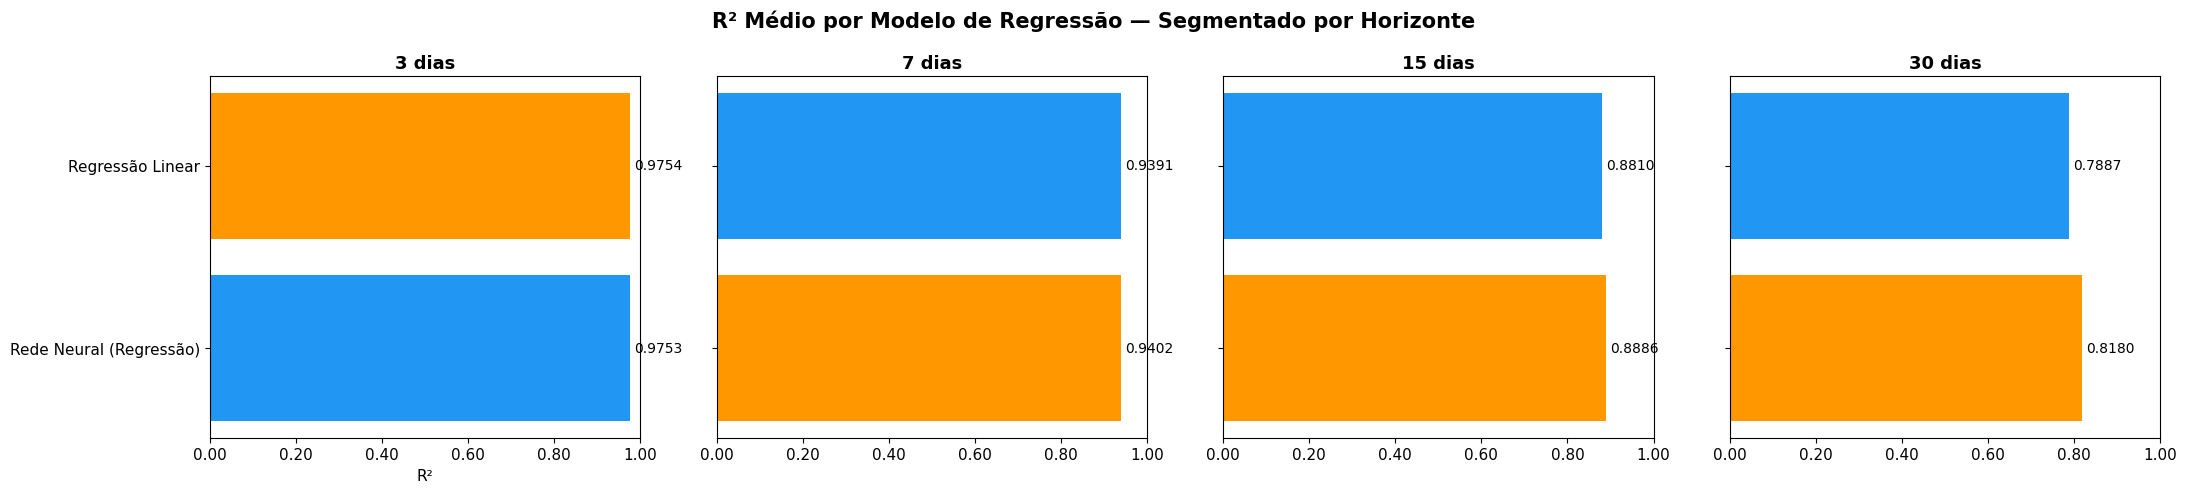

In [13]:
# ============================================================
# GRÁFICO: R² médio por modelo de regressão e horizonte
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('R² Médio por Modelo de Regressão — Segmentado por Horizonte', fontsize=15, fontweight='bold')

cores_regressao = ['#2196F3', '#FF9800']

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue
    
    media = df_h.groupby('modelo_nome')['R2'].mean().sort_values(ascending=True)
    bars = ax.barh(media.index, media.values, color=cores_regressao[:len(media)])
    ax.set_title(horizonte, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    
    for bar, val in zip(bars, media.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
                va='center', fontsize=10)

axes[0].set_xlabel('R²')
plt.tight_layout()
plt.savefig('ranking_regressao_r2.png', bbox_inches='tight', dpi=150)
plt.show()

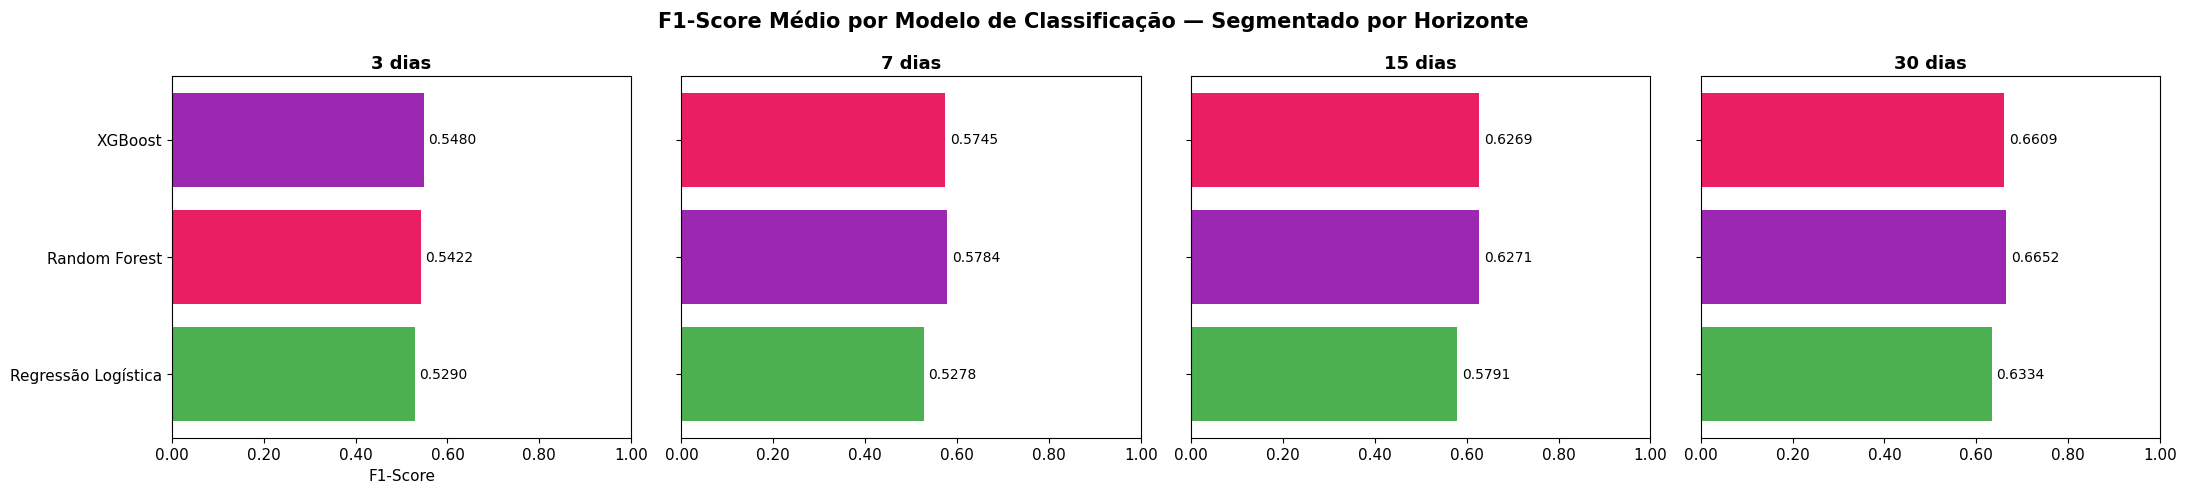

In [14]:
# ============================================================
# GRÁFICO: F1-Score médio por modelo de classificação e horizonte
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('F1-Score Médio por Modelo de Classificação — Segmentado por Horizonte', fontsize=15, fontweight='bold')

cores_classificacao = ['#4CAF50', '#E91E63', '#9C27B0']

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue
    
    media = df_h.groupby('modelo_nome')['F1-Score'].mean().sort_values(ascending=True)
    bars = ax.barh(media.index, media.values, color=cores_classificacao[:len(media)])
    ax.set_title(horizonte, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    
    for bar, val in zip(bars, media.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
                va='center', fontsize=10)

axes[0].set_xlabel('F1-Score')
plt.tight_layout()
plt.savefig('ranking_classificacao_f1.png', bbox_inches='tight', dpi=150)
plt.show()

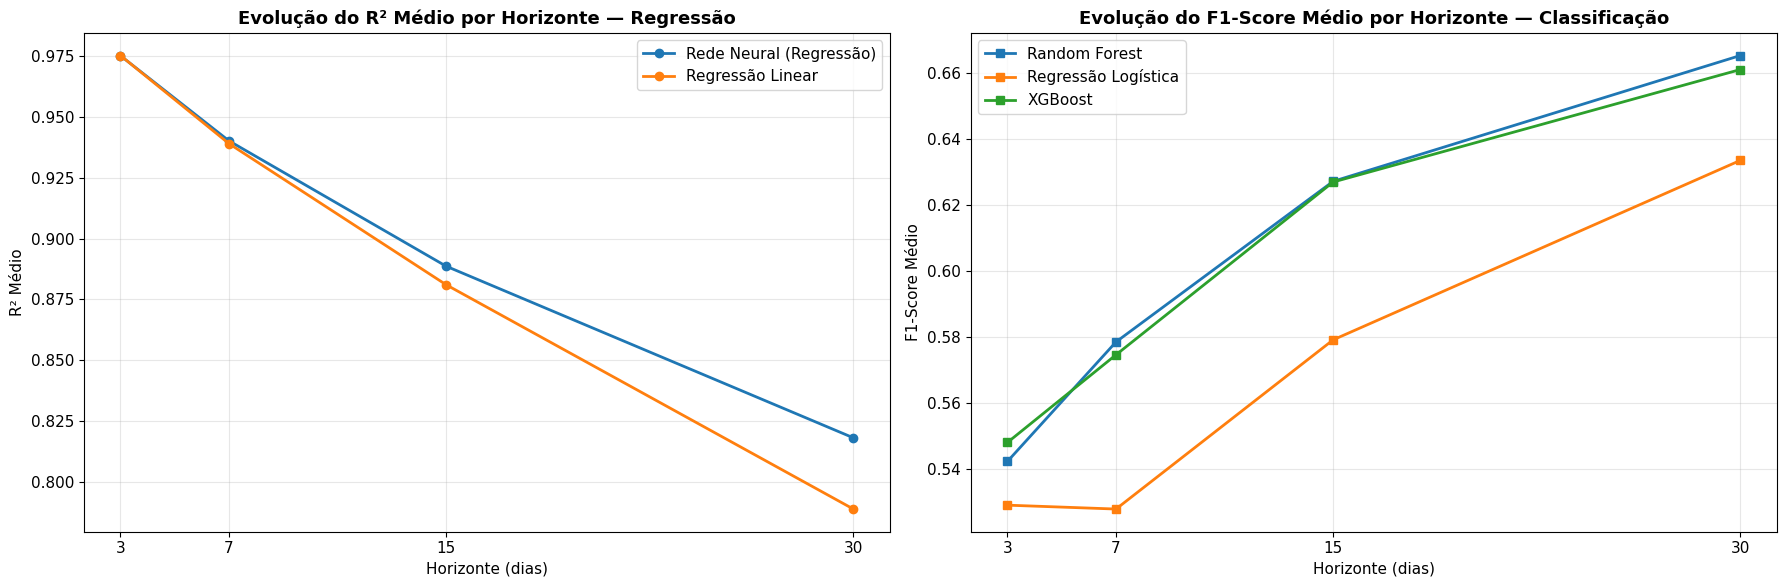

In [15]:
# ============================================================
# GRÁFICO: Evolução das métricas por horizonte (linha)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Regressão: R² por horizonte ---
ax = axes[0]
ax.set_title('Evolução do R² Médio por Horizonte — Regressão', fontsize=13, fontweight='bold')

for modelo in sorted(df_regressao['modelo_nome'].unique()):
    df_m = df_regressao[df_regressao['modelo_nome'] == modelo]
    medias = []
    for h in HORIZONTES:
        val = df_m[df_m['Horizonte'] == h]['R2'].mean()
        medias.append(val)
    ax.plot([3, 7, 15, 30], medias, marker='o', linewidth=2, label=modelo)

ax.set_xlabel('Horizonte (dias)')
ax.set_ylabel('R² Médio')
ax.set_xticks([3, 7, 15, 30])
ax.legend()
ax.grid(True, alpha=0.3)

# --- Classificação: F1-Score por horizonte ---
ax = axes[1]
ax.set_title('Evolução do F1-Score Médio por Horizonte — Classificação', fontsize=13, fontweight='bold')

for modelo in sorted(df_classificacao['modelo_nome'].unique()):
    df_m = df_classificacao[df_classificacao['modelo_nome'] == modelo]
    medias = []
    for h in HORIZONTES:
        val = df_m[df_m['Horizonte'] == h]['F1-Score'].mean()
        medias.append(val)
    ax.plot([3, 7, 15, 30], medias, marker='s', linewidth=2, label=modelo)

ax.set_xlabel('Horizonte (dias)')
ax.set_ylabel('F1-Score Médio')
ax.set_xticks([3, 7, 15, 30])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolucao_metricas_horizonte.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Ranking por Ticker (detalhamento)

In [16]:
tickers = sorted(df_all['ticker'].unique())

print('=' * 80)
print('  RANKING POR TICKER — REGRESSÃO')
print('=' * 80)

for ticker in tickers:
    for horizonte in HORIZONTES:
        df_h = df_regressao[(df_regressao['ticker'] == ticker) & (df_regressao['Horizonte'] == horizonte)]
        if df_h.empty:
            continue
        
        df_h = df_h.sort_values('R2', ascending=False).reset_index(drop=True)
        df_h.index = df_h.index + 1
        df_h.index.name = 'Ranking'
        
        print(f'\n--- {ticker} | {horizonte} ---')
        display(df_h[['modelo_nome', 'dataset_nome', 'R2', 'MAE', 'RMSE']].rename(columns={
            'modelo_nome': 'Modelo', 'dataset_nome': 'Dataset'
        }))

  RANKING POR TICKER — REGRESSÃO

--- AGRO3 | 3 dias ---


,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Regressão Linear,Indicadores,0.9896,0.4077,0.6075
2,Rede Neural (Regressão),Janelas,0.9895,0.4270,0.6219
3,Rede Neural (Regressão),Indicadores,0.9894,0.4108,0.6136
4,Regressão Linear,Base,0.9892,0.4198,0.6172
5,Regressão Linear,Janelas,0.9892,0.4293,0.6295
6,Rede Neural (Regressão),Base,0.9889,0.4204,0.6249
7,Rede Neural (Regressão),Dummy,0.9889,0.4204,0.6249
8,Regressão Linear,Dummy,0.9887,0.4266,0.6309



--- AGRO3 | 7 dias ---


,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Rede Neural (Regressão),Indicadores,0.9780,0.6050,0.8775
2,Rede Neural (Regressão),Janelas,0.9773,0.6107,0.9134
3,Regressão Linear,Indicadores,0.9772,0.6087,0.8929
4,Regressão Linear,Base,0.9771,0.6106,0.9090
5,Rede Neural (Regressão),Base,0.9769,0.6113,0.9121
6,Rede Neural (Regressão),Dummy,0.9769,0.6113,0.9121
7,Regressão Linear,Janelas,0.9764,0.6223,0.9311
8,Regressão Linear,Dummy,0.9759,0.6222,0.9323



--- AGRO3 | 15 dias ---


...

,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Rede Neural (Regressão),Janelas,0.8910,0.4748,0.6394
2,Regressão Linear,Janelas,0.8873,0.4807,0.6502
3,Regressão Linear,Base,0.8585,0.5556,0.7006
4,Regressão Linear,Dummy,0.8584,0.5554,0.7010
5,Rede Neural (Regressão),Dummy,0.8562,0.5599,0.7063
6,Rede Neural (Regressão),Base,0.8562,0.5599,0.7063
7,Rede Neural (Regressão),Indicadores,0.8489,0.5445,0.7122
8,Regressão Linear,Indicadores,0.8394,0.5601,0.7342



--- SOJA3 | 15 dias ---


,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Rede Neural (Regressão),Janelas,0.7816,0.6724,0.9122
2,Regressão Linear,Janelas,0.7533,0.7256,0.9695
3,Rede Neural (Regressão),Base,0.7429,0.7041,0.9112
4,Rede Neural (Regressão),Dummy,0.7429,0.7041,0.9112
5,Regressão Linear,Base,0.7318,0.7185,0.9307
6,Regressão Linear,Dummy,0.7314,0.7195,0.9313
7,Rede Neural (Regressão),Indicadores,0.7125,0.8287,1.0708
8,Regressão Linear,Indicadores,0.6903,0.8523,1.1114



--- SOJA3 | 30 dias ---


,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Rede Neural (Regressão),Indicadores,0.6061,1.0248,1.3013
2,Rede Neural (Regressão),Janelas,0.5965,1.0544,1.3153
3,Rede Neural (Regressão),Dummy,0.5918,0.9496,1.2198
4,Rede Neural (Regressão),Base,0.5918,0.9496,1.2198
5,Regressão Linear,Janelas,0.5431,1.1140,1.3997
6,Regressão Linear,Indicadores,0.5407,1.1303,1.4052
7,Regressão Linear,Dummy,0.5338,1.0000,1.3035
8,Regressão Linear,Base,0.5335,1.0026,1.3039


In [17]:
print('=' * 80)
print('  RANKING POR TICKER — CLASSIFICAÇÃO')
print('=' * 80)

for ticker in tickers:
    for horizonte in HORIZONTES:
        df_h = df_classificacao[(df_classificacao['ticker'] == ticker) & (df_classificacao['Horizonte'] == horizonte)]
        if df_h.empty:
            continue
        
        df_h = df_h.sort_values('F1-Score', ascending=False).reset_index(drop=True)
        df_h.index = df_h.index + 1
        df_h.index.name = 'Ranking'
        
        print(f'\n--- {ticker} | {horizonte} ---')
        display(df_h[['modelo_nome', 'dataset_nome', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].rename(columns={
            'modelo_nome': 'Modelo', 'dataset_nome': 'Dataset'
        }))

  RANKING POR TICKER — CLASSIFICAÇÃO

--- AGRO3 | 3 dias ---


,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,XGBoost,Janelas,0.5748,0.5741,0.5748,0.5741,0.5975
2,Random Forest,Janelas,0.5689,0.5685,0.5689,0.5686,0.5915
3,XGBoost,Dummy,0.5702,0.5694,0.5702,0.5667,0.6011
4,XGBoost,Base,0.5702,0.5694,0.5702,0.5667,0.6011
5,Random Forest,Base,0.5468,0.5480,0.5468,0.5468,0.6170
6,Random Forest,Dummy,0.5468,0.5480,0.5468,0.5468,0.6170
7,Regressão Logística,Dummy,0.5673,0.5729,0.5673,0.5460,0.5633
8,Random Forest,Indicadores,0.5355,0.5362,0.5355,0.5356,0.5625
9,XGBoost,Indicadores,0.5355,0.5362,0.5355,0.5356,0.5706



--- AGRO3 | 7 dias ---


,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,Random Forest,Base,0.6023,0.5986,0.6023,0.5975,0.6327
2,Random Forest,Dummy,0.6023,0.5986,0.6023,0.5975,0.6327
3,XGBoost,Dummy,0.6140,0.6161,0.6140,0.5915,0.6015
4,XGBoost,Base,0.6140,0.6161,0.6140,0.5915,0.6015
5,XGBoost,Indicadores,0.5562,0.5495,0.5562,0.5485,0.5693
6,Regressão Logística,Dummy,0.5819,0.5857,0.5819,0.5308,0.5885
7,XGBoost,Janelas,0.5249,0.5196,0.5249,0.5205,0.5420
8,Random Forest,Indicadores,0.5237,0.5183,0.5237,0.5194,0.5614
9,Random Forest,Janelas,0.5044,0.5018,0.5044,0.5028,0.5219



--- AGRO3 | 15 dias ---


...

,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,Regressão Logística,Indicadores,0.5747,0.5763,0.5747,0.5736,0.6537
2,Random Forest,Indicadores,0.5517,0.5517,0.5517,0.5505,0.5553
3,Random Forest,Base,0.5506,0.5505,0.5506,0.5504,0.5861
4,Random Forest,Dummy,0.5506,0.5505,0.5506,0.5504,0.5861
5,XGBoost,Indicadores,0.5517,0.5520,0.5517,0.5492,0.5865
6,XGBoost,Janelas,0.5480,0.5485,0.5480,0.5480,0.5824
7,Regressão Logística,Dummy,0.5506,0.5552,0.5506,0.5442,0.6091
8,Random Forest,Janelas,0.5424,0.5427,0.5424,0.5424,0.5593
9,Regressão Logística,Base,0.5337,0.5343,0.5337,0.5332,0.5943



--- SOJA3 | 15 dias ---


,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,Random Forest,Indicadores,0.6724,0.6738,0.6724,0.6726,0.7208
2,XGBoost,Indicadores,0.6724,0.6786,0.6724,0.6717,0.7481
3,XGBoost,Janelas,0.6384,0.6379,0.6384,0.6378,0.6507
4,Regressão Logística,Dummy,0.6348,0.6350,0.6348,0.6349,0.6843
5,Regressão Logística,Base,0.6236,0.6238,0.6236,0.6237,0.6834
6,Random Forest,Janelas,0.6158,0.6150,0.6158,0.6147,0.6357
7,XGBoost,Base,0.6124,0.6126,0.6124,0.6081,0.6603
8,XGBoost,Dummy,0.6124,0.6126,0.6124,0.6081,0.6603
9,Regressão Logística,Janelas,0.6045,0.6064,0.6045,0.6047,0.6687



--- SOJA3 | 30 dias ---


,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,Regressão Logística,Indicadores,0.7011,0.7011,0.7011,0.7011,0.7412
2,Random Forest,Dummy,0.6910,0.6906,0.6910,0.6908,0.7560
3,Random Forest,Base,0.6910,0.6906,0.6910,0.6908,0.7560
4,Regressão Logística,Base,0.6854,0.6835,0.6854,0.6837,0.7137
5,Regressão Logística,Dummy,0.6854,0.6835,0.6854,0.6837,0.7223
6,XGBoost,Base,0.6742,0.6733,0.6742,0.6737,0.7636
7,XGBoost,Dummy,0.6742,0.6733,0.6742,0.6737,0.7636
8,Regressão Logística,Janelas,0.6723,0.6704,0.6723,0.6706,0.7148
9,XGBoost,Indicadores,0.6379,0.6346,0.6379,0.6326,0.7080


---
## 8. Heatmaps: Desempenho por Modelo × Dataset

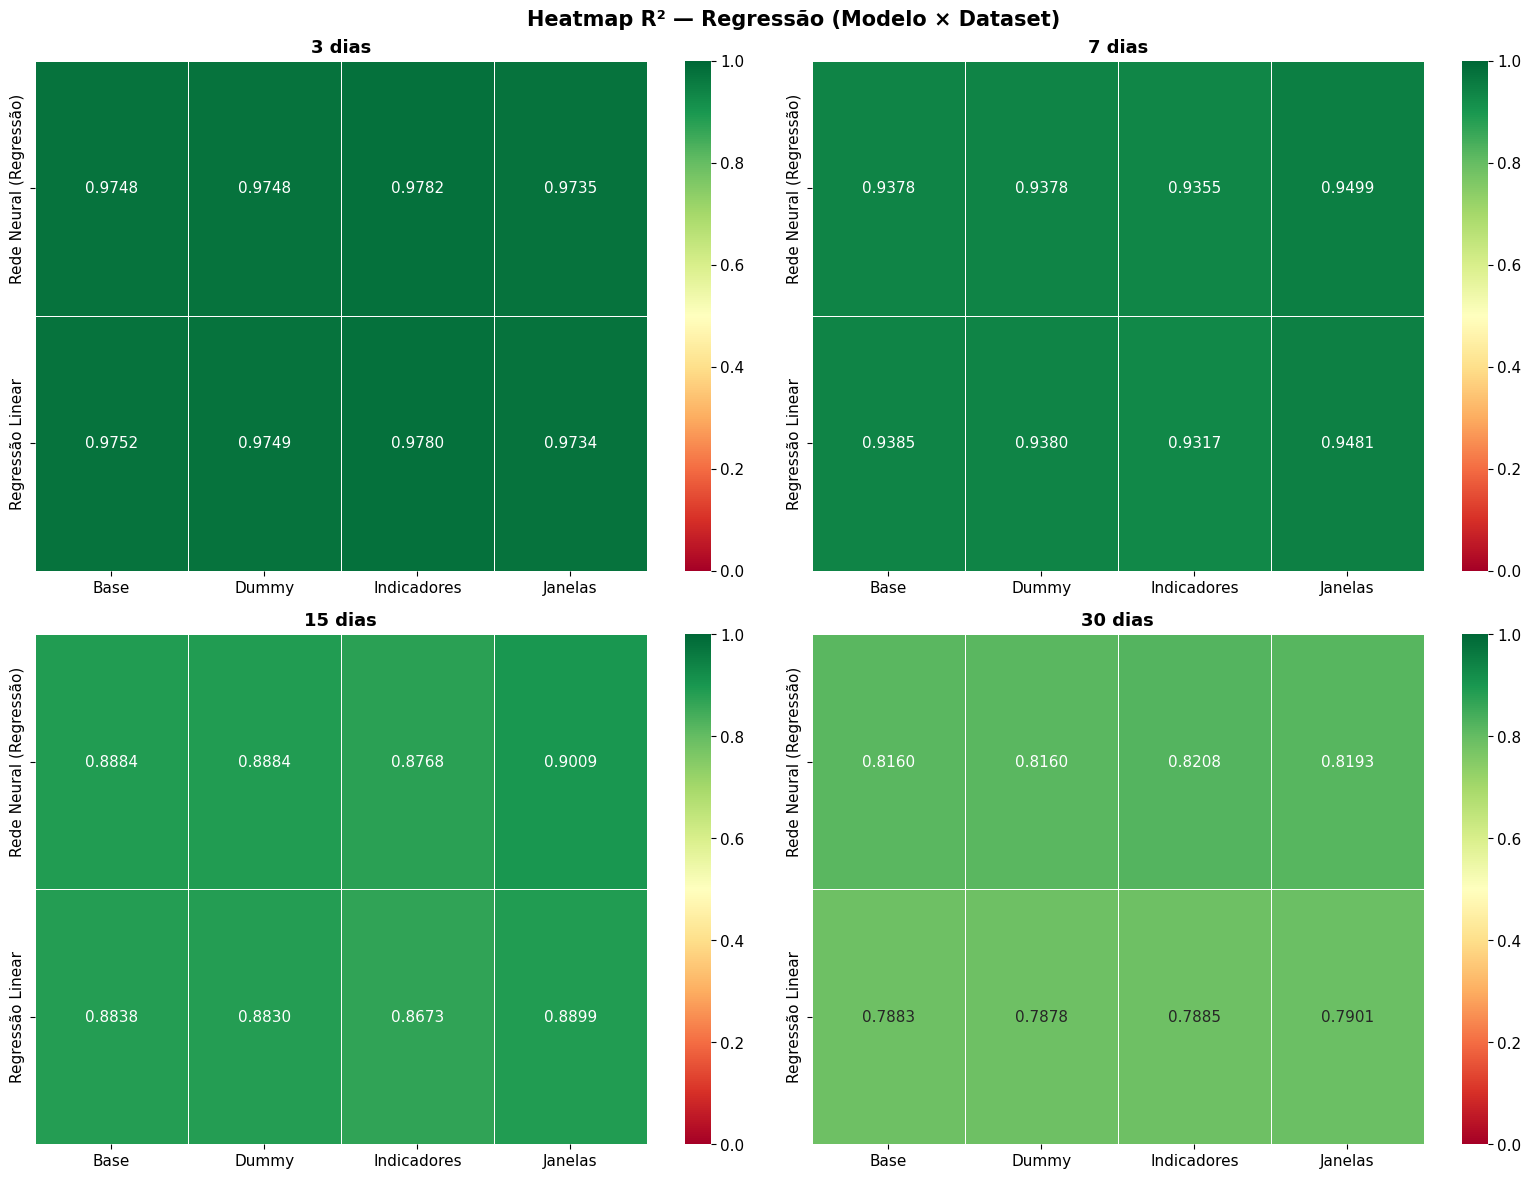

In [18]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Heatmap R² — Regressão (Modelo × Dataset)', fontsize=15, fontweight='bold')

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i // 2][i % 2]
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    
    if df_h.empty:
        ax.set_title(f'{horizonte} (sem dados)')
        continue
    
    pivot = df_h.pivot_table(
        values='R2', index='modelo_nome', columns='dataset_nome', aggfunc='mean'
    )
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{horizonte}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_regressao_r2.png', bbox_inches='tight', dpi=150)
plt.show()

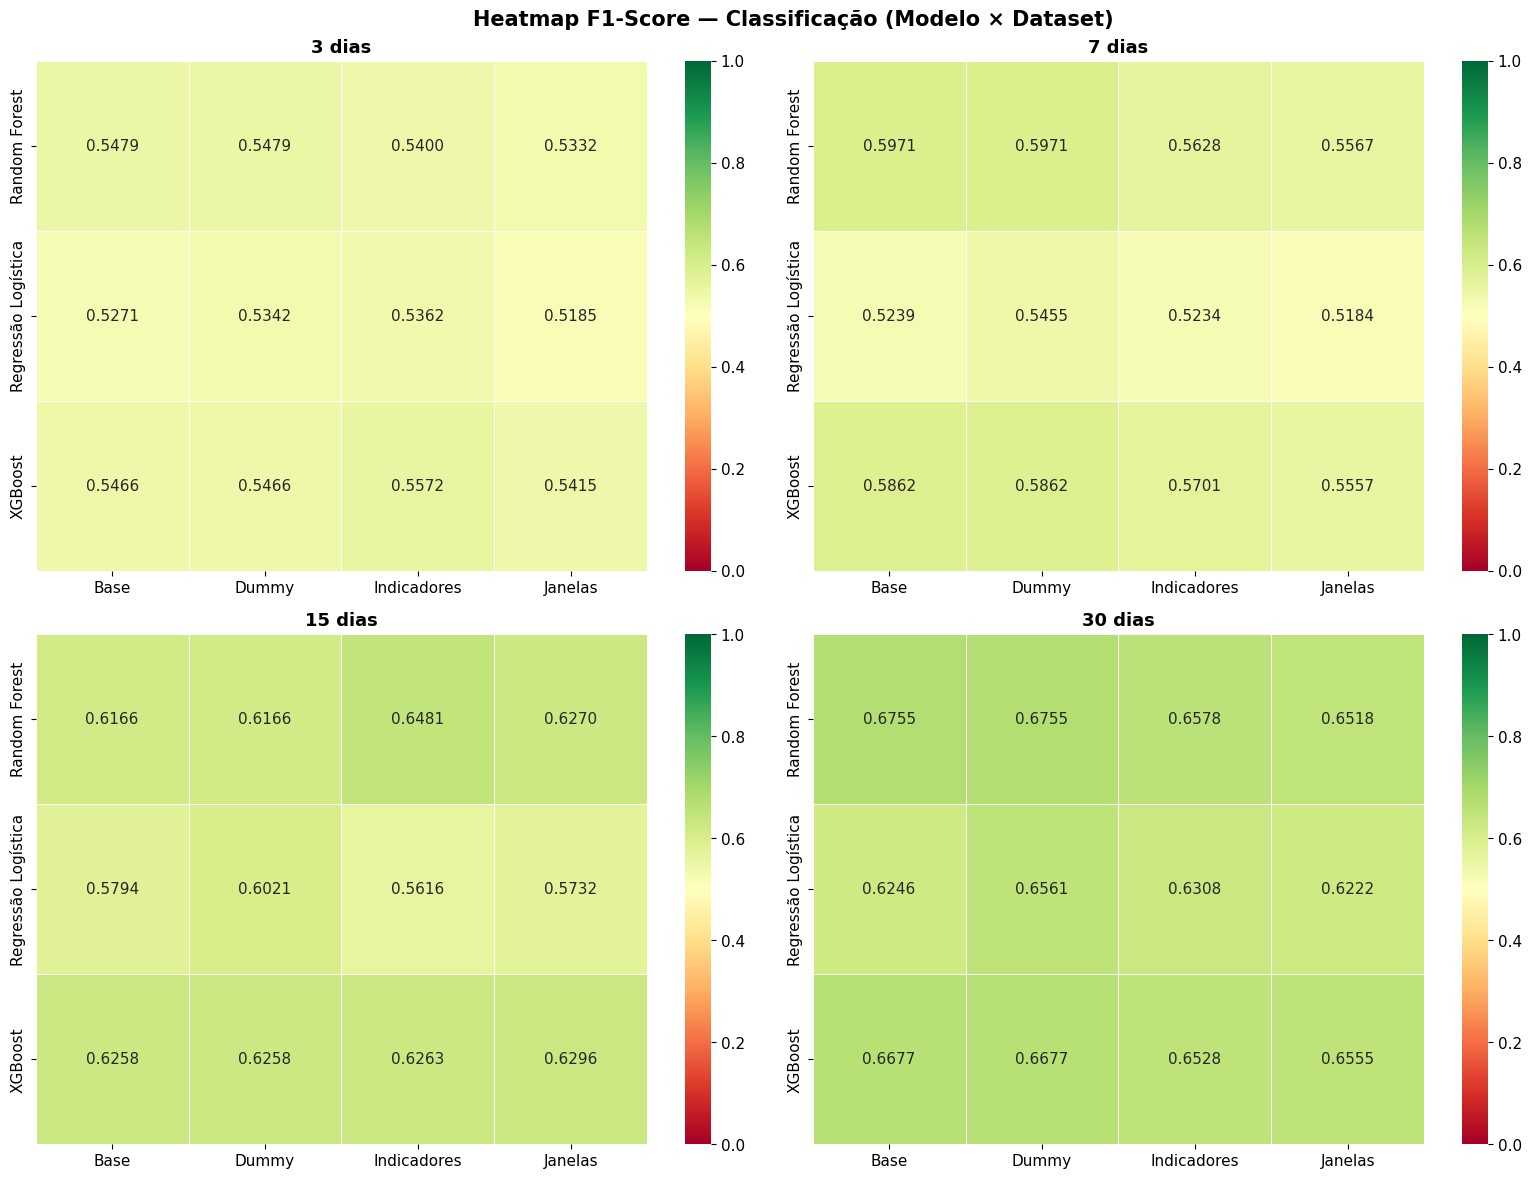

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Heatmap F1-Score — Classificação (Modelo × Dataset)', fontsize=15, fontweight='bold')

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i // 2][i % 2]
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    
    if df_h.empty:
        ax.set_title(f'{horizonte} (sem dados)')
        continue
    
    pivot = df_h.pivot_table(
        values='F1-Score', index='modelo_nome', columns='dataset_nome', aggfunc='mean'
    )
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{horizonte}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_classificacao_f1.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Resumo Final: Melhor Modelo por Horizonte

In [20]:
print('=' * 80)
print('  MELHOR MODELO POR HORIZONTE')
print('=' * 80)

resumo_regressao = []
resumo_classificacao = []

for horizonte in HORIZONTES:
    # Regressão: melhor R²
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if not df_h.empty:
        best = df_h.loc[df_h['R2'].idxmax()]
        resumo_regressao.append({
            'Horizonte': horizonte,
            'Modelo': best['modelo_nome'],
            'Dataset': best['dataset_nome'],
            'Ticker': best['ticker'],
            'R2': best['R2'],
            'MAE': best['MAE'],
            'RMSE': best['RMSE'],
        })
    
    # Classificação: melhor F1-Score
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if not df_h.empty:
        best = df_h.loc[df_h['F1-Score'].idxmax()]
        resumo_classificacao.append({
            'Horizonte': horizonte,
            'Modelo': best['modelo_nome'],
            'Dataset': best['dataset_nome'],
            'Ticker': best['ticker'],
            'Accuracy': best['Accuracy'],
            'F1-Score': best['F1-Score'],
            'AUC-ROC': best['AUC-ROC'],
        })

print('\n--- Regressão (melhor R²) ---')
display(pd.DataFrame(resumo_regressao).set_index('Horizonte'))

print('\n--- Classificação (melhor F1-Score) ---')
display(pd.DataFrame(resumo_classificacao).set_index('Horizonte'))

  MELHOR MODELO POR HORIZONTE

--- Regressão (melhor R²) ---


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Horizonte,,,,,,
3 dias,Regressão Linear,Janelas,SLCE3,0.9919,0.3580,0.4863
7 dias,Rede Neural (Regressão),Janelas,SLCE3,0.9815,0.5413,0.7275
15 dias,Rede Neural (Regressão),Base,SLCE3,0.9658,0.7285,0.9774
30 dias,Rede Neural (Regressão),Indicadores,SLCE3,0.9372,0.9942,1.2981



--- Classificação (melhor F1-Score) ---


,Modelo,Dataset,Ticker,Accuracy,F1-Score,AUC-ROC
Horizonte,,,,,,
3 dias,XGBoost,Indicadores,SOJA3,0.6034,0.6034,0.5868
7 dias,Random Forest,Base,SLCE3,0.6433,0.6435,0.7145
15 dias,Random Forest,Indicadores,SOJA3,0.6724,0.6726,0.7208
30 dias,Regressão Logística,Indicadores,SOJA3,0.7011,0.7011,0.7412


---
## 10. Exportar Rankings Consolidados

In [21]:
# Exportar CSVs consolidados para análise posterior
output_dir = os.path.dirname(os.path.abspath('__file__'))

df_regressao.to_csv(os.path.join(output_dir, 'consolidado_regressao.csv'), index=False)
df_classificacao.to_csv(os.path.join(output_dir, 'consolidado_classificacao.csv'), index=False)

# Rankings médios por modelo e horizonte
ranking_medio_reg = []
ranking_medio_clf = []

for horizonte in HORIZONTES:
    # Regressão
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if not df_h.empty:
        media = df_h.groupby('modelo_nome')[['R2', 'MAE', 'RMSE']].mean().reset_index()
        media['Horizonte'] = horizonte
        ranking_medio_reg.append(media)
    
    # Classificação
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if not df_h.empty:
        media = df_h.groupby('modelo_nome')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].mean().reset_index()
        media['Horizonte'] = horizonte
        ranking_medio_clf.append(media)

if ranking_medio_reg:
    pd.concat(ranking_medio_reg).to_csv(os.path.join(output_dir, 'ranking_medio_regressao.csv'), index=False)

if ranking_medio_clf:
    pd.concat(ranking_medio_clf).to_csv(os.path.join(output_dir, 'ranking_medio_classificacao.csv'), index=False)

print('Arquivos exportados com sucesso:')
print('  - consolidado_regressao.csv')
print('  - consolidado_classificacao.csv')
print('  - ranking_medio_regressao.csv')
print('  - ranking_medio_classificacao.csv')

Arquivos exportados com sucesso:
  - consolidado_regressao.csv
  - consolidado_classificacao.csv
  - ranking_medio_regressao.csv
  - ranking_medio_classificacao.csv
